<a href="https://colab.research.google.com/github/ChSivamowny15/RESNET-50/blob/main/RESNET50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
a#Importing all required libraries
import tensorflow as tf
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.applications import *
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.utils import load_img

In [ ]:
#Augmentation
lt = [cv2.ROTATE_180,cv2.ROTATE_90_COUNTERCLOCKWISE,cv2.ROTATE_90_CLOCKWISE]
def brightness(img):
    value = random.uniform(0.5, 2)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hsv = np.array(hsv, dtype = np.float64)
    hsv[:,:,1] = hsv[:,:,1]*value
    hsv[:,:,1][hsv[:,:,1]>255] = 255
    hsv[:,:,2] = hsv[:,:,2]*value
    hsv[:,:,2][hsv[:,:,2]>255]= 255
    hsv = np.array(hsv, dtype = np.uint8)
    img = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    return img

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pathlib
import glob
directory=pathlib.Path("/content/drive/My Drive/Cartoons Dataset")
resultant="/content/augmentedimages"
items=os.listdir(directory)
classes=[]
count=0
images=[]
labels=[]
for i in items:
    i1=0
    print(i)
    classes.append(i)
    path1=f"{directory}/{i}"
    a=random.randint(5,10)
    img=cv2.imread(path1)
    img=cv2.resize(img,(224,224))
    k=i.split(".")[0]
    cv2.imwrite(f"{resultant}\{k}{i1}.png",img)

    i1+=1
    while a!=0:
      img=cv2.rotate(img,lt[random.randint(0,2)])
      images.append(img)
      cv2.imwrite(f"{resultant}\{k}{i1}.png",img)
      i1+=1
      labels.append(count)
      if a%2==0:
        img = brightness(img)
        images.append(img)
        cv2.imwrite(f"{resultant}\{k}{i1}.png",img)
        i1+=1
        labels.append(count)
      a-=1
    count+=1
images=np.array(images)
labels=np.array(labels)

<>:19: SyntaxWarning: invalid escape sequence '\{'
<>:25: SyntaxWarning: invalid escape sequence '\{'
<>:31: SyntaxWarning: invalid escape sequence '\{'
<>:19: SyntaxWarning: invalid escape sequence '\{'
<>:25: SyntaxWarning: invalid escape sequence '\{'
<>:31: SyntaxWarning: invalid escape sequence '\{'
/tmp/ipython-input-4167289641.py:19: SyntaxWarning: invalid escape sequence '\{'
  cv2.imwrite(f"{resultant}\{k}{i1}.png",img)
/tmp/ipython-input-4167289641.py:25: SyntaxWarning: invalid escape sequence '\{'
  cv2.imwrite(f"{resultant}\{k}{i1}.png",img)
/tmp/ipython-input-4167289641.py:31: SyntaxWarning: invalid escape sequence '\{'
  cv2.imwrite(f"{resultant}\{k}{i1}.png",img)


Ben10.jpg
Hagemaru.jpg
Tom and jerry.jpg
Roll_No.21.jpg
Shinchan.jpg
Jackie_Chan.jpg
Heidi.jpg
Doreamon.jpg
Ninja Hatori.jpg
Dragon booster.jpg
Chota bheem.jpg
Little krishna.jpg
Kick buttowski.jpg
Huddy mera buddy.jpg
Oggy and cockroaches.jpg
Chikoo aur bunty.jpg
Pokemon.jpg
Dora.jpg
Phineas and ferb.jpg
Motu patlu.jpg


In [ ]:
images.shape

(211, 224, 224, 3)

In [ ]:
from keras.layers import Dense,Dropout, Flatten
from tensorflow.keras.models import *
from keras.applications import ResNet50

In [ ]:
#Using ResNet50 pretrained model
model=ResNet50(weights="imagenet",include_top=False,input_shape=(224,224,3))
for i in model.layers:
  i.trainable=False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
len(model.layers)

175

In [ ]:
model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.keras.layers import AveragePooling2D, Dropout, Flatten, Dense
transferresnet=Sequential()
#adding pretrained model
transferresnet.add(model)
#adding customer layers
transferresnet.add(GlobalAveragePooling2D())
transferresnet.add(Dense(512,activation="relu"))
transferresnet.add(Dense(128,activation="relu"))
transferresnet.add(Dense(20,activation="softmax"))

In [ ]:
transferresnet.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,705,044 (94.24 MB)

 Trainable params: 1,117,332 (4.26 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
import tensorflow as tf
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self,epoch,logs={}):
    print("call")
    if(logs.get('accuracy')>.99):
      print("\nReached %2.2f%% accuracy, so stopping training"%(99))
      self.model.stop_training=True
callbacks=myCallback()

In [ ]:
transferresnet.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
transferresnet.fit(images,labels,epochs=100,callbacks=[callbacks])

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.3033 - loss: 2.5972call
7/7 ━━━━━━━━━━━━━━━━━━━━ 51s 6s/step - accuracy: 0.3288 - loss: 2.5070
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9703 - loss: 0.2628call
7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 6s/step - accuracy: 0.9711 - loss: 0.2544
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 1.0000 - loss: 0.0292call

Reached 99.00% accuracy, so stopping training
7/7 ━━━━━━━━━━━━━━━━━━━━ 82s 6s/step - accuracy: 1.0000 - loss: 0.0286


In [ ]:
transferresnet.evaluate(images,labels)

7/7 ━━━━━━━━━━━━━━━━━━━━ 47s 6s/step - accuracy: 1.0000 - loss: 0.0105


[0.009914157912135124, 1.0]

In [ ]:
def predict(i,transferresnet,labels):
  path1=f"{directory}/{i}"
  img=cv2.imread(path1)
  img=cv2.resize(img,(224,224))
  a=np.argmax(transferresnet.predict(np.array([img])))
  img=cv2.putText(img,labels[a],(25,25),cv2.FONT_HERSHEY_SIMPLEX,1,(225,225,0),3,cv2.LINE_AA)
  plt.imshow(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


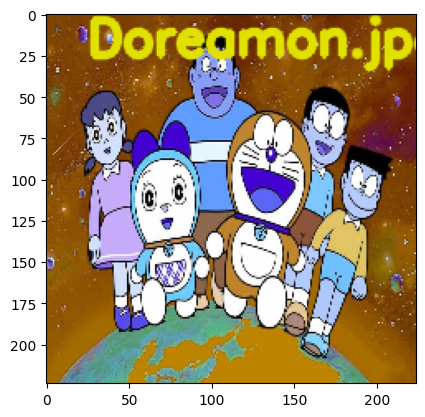

In [ ]:
predict("Doreamon.jpg",transferresnet,classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step


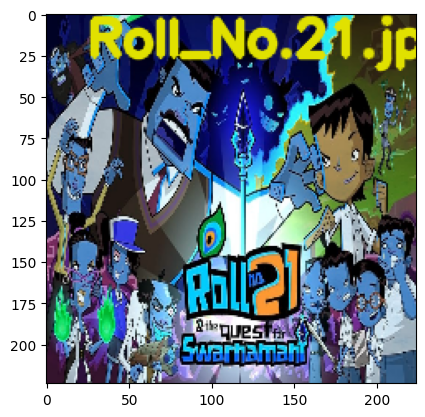

In [ ]:
predict("Roll_No.21.jpg",transferresnet,classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step


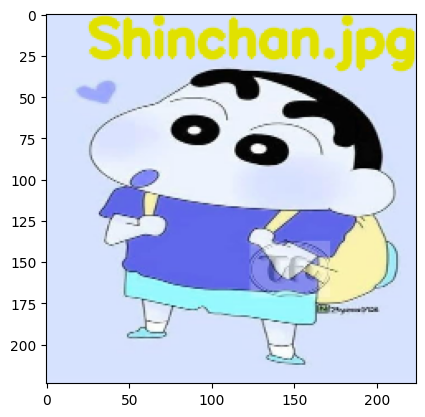

In [ ]:
predict("Shinchan.jpg",transferresnet,classes)